model file on google drive

https://drive.google.com/file/d/1KsKqM45jmy8mPcKndVYjgbsAeWSXZnZf/view?usp=sharing

In [24]:
import os, torch, nltk
import pandas as pd
from PIL import Image
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from transformers import GPT2Tokenizer, GPT2LMHeadModel
from timm import create_model
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from pycocoevalcap.cider.cider import Cider
import matplotlib.pyplot as plt

nltk.download("punkt")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [6]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

IMG_SIZE = 224
BATCH_SIZE = 16
MAX_LEN = 40
EPOCHS = 10
LR = 5e-5
PATIENCE = 3
BEST_PATH = "best_image_caption_model.pth"

In [7]:
df = pd.read_csv("flickr8k/captions.txt")
df["caption"] = df["caption"].str.lower().str.strip()
df["caption"] = "<bos> " + df["caption"] + " <eos>"

In [8]:
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
tokenizer.add_special_tokens({
    "bos_token": "<bos>",
    "eos_token": "<eos>",
    "pad_token": "<pad>"
})

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

3

In [9]:
class FlickrDataset(Dataset):
    def __init__(self, df, img_dir):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir

        self.transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std =[0.229, 0.224, 0.225]
            )
        ])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img = Image.open(
            os.path.join(self.img_dir, row.image)
        ).convert("RGB")
        img = self.transform(img)

        tokens = tokenizer(
            row.caption,
            padding="max_length",
            truncation=True,
            max_length=MAX_LEN,
            return_tensors="pt"
        )

        return (
            img,
            tokens.input_ids.squeeze(),
            tokens.attention_mask.squeeze()
        )

In [10]:
unique_images = df.image.unique()

train_imgs, temp_imgs = train_test_split(
    unique_images, test_size=0.2, random_state=42
)

val_imgs, test_imgs = train_test_split(
    temp_imgs, test_size=0.5, random_state=42
)

train_df = df[df.image.isin(train_imgs)]
val_df   = df[df.image.isin(val_imgs)]
test_df  = df[df.image.isin(test_imgs)]

print("Train images:", len(train_imgs))
print("Val images:", len(val_imgs))
print("Test images:", len(test_imgs))

Train images: 6472
Val images: 809
Test images: 810


In [11]:
train_loader = DataLoader(
    FlickrDataset(train_df, "flickr8k/Images"),
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    FlickrDataset(val_df, "flickr8k/Images"),
    batch_size=1,
    shuffle=False
)

test_loader = DataLoader(
    FlickrDataset(test_df, "flickr8k/Images"),
    batch_size=1,
    shuffle=False
)

In [12]:
class ImageCaptionModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = create_model(
            "efficientnet_b3",
            pretrained=True,
            num_classes=0
        )

        self.proj = nn.Linear(
            self.encoder.num_features, 768
        )

        self.decoder = GPT2LMHeadModel.from_pretrained("gpt2")
        self.decoder.resize_token_embeddings(len(tokenizer))

    def forward(self, images, input_ids, attention_mask):
        img_feat = self.encoder(images)
        img_embed = self.proj(img_feat).unsqueeze(1)

        text_embed = self.decoder.transformer.wte(input_ids)
        inputs_embeds = torch.cat([img_embed, text_embed], dim=1)

        B = input_ids.size(0)

        image_labels = torch.full(
            (B, 1), -100, device=input_ids.device
        )
        labels = torch.cat([image_labels, input_ids], dim=1)

        image_mask = torch.ones((B, 1), device=attention_mask.device)
        attention_mask = torch.cat([image_mask, attention_mask], dim=1)

        out = self.decoder(
            inputs_embeds=inputs_embeds,
            attention_mask=attention_mask,
            labels=labels
        )
        return out.loss

In [13]:
model = ImageCaptionModel().to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


In [14]:
def evaluate_val_loss(model, loader):
    model.eval()
    total = 0

    with torch.no_grad():
        for imgs, ids, mask in loader:
            imgs, ids, mask = imgs.to(DEVICE), ids.to(DEVICE), mask.to(DEVICE)
            loss = model(imgs, ids, mask)
            total += loss.item()

    return total / len(loader)

In [15]:
def evaluate_cider(loader, df_split):
    cider = Cider()
    gts, res = {}, {}
    idx = 0

    for img, _, _ in tqdm(loader):
        img = img.to(DEVICE)
        pred = beam_search(img[0])

        img_name = df_split.iloc[idx].image
        refs = df_split[df_split.image == img_name].caption.tolist()
        refs = [r.replace("<bos>", "").replace("<eos>", "") for r in refs]

        gts[idx] = refs
        res[idx] = [pred]
        idx += 1

    score, _ = cider.compute_score(gts, res)
    return score

In [16]:
def beam_search(image, beam_size=3, max_len=40):
    model.eval()

    with torch.no_grad():
        img_feat = model.encoder(image.unsqueeze(0).to(DEVICE))
        img_embed = model.proj(img_feat).unsqueeze(1)

        sequences = [(torch.tensor([[tokenizer.bos_token_id]], device=DEVICE), 0.0)]

        for _ in range(max_len):
            all_candidates = []

            for seq, score in sequences:
                text_embed = model.decoder.transformer.wte(seq)
                inputs = torch.cat([img_embed, text_embed], dim=1)

                logits = model.decoder(inputs_embeds=inputs).logits[:, -1]
                probs = torch.log_softmax(logits, dim=-1)
                topk = torch.topk(probs, beam_size)

                for i in range(beam_size):
                    next_seq = torch.cat(
                        [seq, topk.indices[:, i].unsqueeze(1)], dim=1
                    )
                    all_candidates.append(
                        (next_seq, score + topk.values[:, i].item())
                    )

            sequences = sorted(all_candidates, key=lambda x: x[1], reverse=True)[:beam_size]

        return tokenizer.decode(sequences[0][0][0], skip_special_tokens=True)

In [17]:
start_epoch = 0
best_val_loss = float("inf")
patience_counter = 0

if os.path.exists(BEST_PATH):
    print(f"Loading checkpoint from {BEST_PATH}")

    checkpoint = torch.load(BEST_PATH, map_location=DEVICE)

    model.load_state_dict(checkpoint["model"])
    optimizer.load_state_dict(checkpoint["optimizer"])

    start_epoch = checkpoint["epoch"] + 1
    best_val_loss = checkpoint["val_loss"]

    print(
        f"Resumed from epoch {start_epoch}, "
        f"best val loss = {best_val_loss:.4f}"
    )

In [18]:
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for imgs, ids, mask in tqdm(train_loader):
        imgs, ids, mask = imgs.to(DEVICE), ids.to(DEVICE), mask.to(DEVICE)

        loss = model(imgs, ids, mask)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    train_loss = total_loss / len(train_loader)
    val_loss = evaluate_val_loss(model, val_loader)

    print(f"\nEpoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val   Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0

        torch.save({
            "model": model.state_dict(),
            "optimizer": optimizer.state_dict(),
            "epoch": epoch,
            "val_loss": val_loss
        }, BEST_PATH)

        print("Best model saved")

    else:
        patience_counter += 1
        print(f"⏸ Patience {patience_counter}/{PATIENCE}")

        if patience_counter >= PATIENCE:
            print("Early stopping")
            break

100%|██████████| 2023/2023 [15:58<00:00,  2.11it/s]



Epoch 1
Train Loss: 1.1204
Val   Loss: 0.7982
Best model saved


100%|██████████| 2023/2023 [15:50<00:00,  2.13it/s]



Epoch 2
Train Loss: 0.7600
Val   Loss: 0.7722
Best model saved


100%|██████████| 2023/2023 [15:48<00:00,  2.13it/s]


...


Epoch 4
Train Loss: 0.6395
Val   Loss: 0.7730
⏸ Patience 1/3


100%|██████████| 2023/2023 [15:49<00:00,  2.13it/s]



Epoch 5
Train Loss: 0.5913
Val   Loss: 0.7825
⏸ Patience 2/3


100%|██████████| 2023/2023 [15:49<00:00,  2.13it/s]



Epoch 6
Train Loss: 0.5489
Val   Loss: 0.7993
⏸ Patience 3/3
Early stopping


In [19]:
ckpt = torch.load(BEST_PATH, map_location=DEVICE)
model.load_state_dict(ckpt["model"])
optimizer.load_state_dict(ckpt["optimizer"])

print("Test CIDEr:", evaluate_cider(test_loader, test_df))

100%|██████████| 4050/4050 [1:25:22<00:00,  1.26s/it]


Test CIDEr: 0.5242185278542838


NameError: name 'checkpoint' is not defined

In [23]:

start_epoch = ckpt["epoch"] + 1
best_val_loss = ckpt["val_loss"]

In [32]:
def try_image(image_path, beam_size=3):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std =[0.229, 0.224, 0.225]
        )
    ])

    img_pil = Image.open(image_path).convert("RGB")

    img_tensor = transform(img_pil).to(DEVICE)

    caption = beam_search(img_tensor, beam_size=beam_size)

    plt.figure(figsize=(6, 6))
    plt.imshow(img_pil)
    plt.axis("off")
    plt.title(f"Caption:\n{caption}", fontsize=12)
    plt.show()

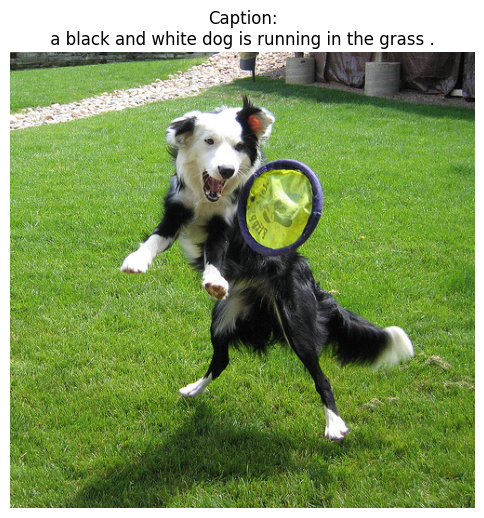

In [33]:
try_image("flickr8k/Images/1067180831_a59dc64344.jpg")